In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/khaidphan/models/pytorch/default/1/best_model_rcnn.pth
/kaggle/input/models/khaidphan/models/pytorch/default/1/best_model_yolov8.pt
/kaggle/input/models/khaidphan/models/pytorch/default/1/best_model_ssd.pth


In [5]:
# !rm -rf /kaggle/working/Basketball-1-yolo

In [6]:
### Download dataset COCO
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="9LrAPmXuhWAvoilYVxbM")
project = rf.workspace("eagle-eye").project("basketball-1zhpe")
version = project.version(1)
dataset = version.download("coco")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.0 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery


Extracting Dataset Version Zip to Basketball-1 in coco:: 100%|██████████| 2607/2607 [00:00<00:00, 8695.03it/s]


In [7]:
!cp -r /kaggle/working/Basketball-1 /kaggle/working/Basketball-1-coco
!rm -rf /kaggle/working/Basketball-1

In [8]:
rf = Roboflow(api_key="2CmzVG8usizmcU8crCA5")

project = rf.workspace("eagle-eye").project("basketball-1zhpe")
version = project.version(1)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Basketball-1 in yolov8:: 100%|██████████| 5210/5210 [00:00<00:00, 10402.79it/s]


In [9]:
!cp -r /kaggle/working/Basketball-1 /kaggle/working/Basketball-1-yolo

In [10]:
!rm -rf /kaggle/working/Basketball-1

In [11]:
# Import the basketball dataset, already pre-split into train-valid-test split
rf = Roboflow(api_key="r2FzjGVV2341qn8vpv2p")
project = rf.workspace("eagle-eye").project("basketball-1zhpe")
dataset = project.version(1).download("voc")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Basketball-1 in voc:: 100%|██████████| 5203/5203 [00:00<00:00, 10263.81it/s]


In [12]:
!cp -r /kaggle/working/Basketball-1 /kaggle/working/Basketball-1-voc 
!rm -rf /kaggle/working/Basketball-1

In [13]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.7 MB/s eta 0:00:00a 0:00:01


In [14]:
### Importing

import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os
from pathlib import Path

import json
from collections import defaultdict
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDClassificationHead
import torch.optim as optim

from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [15]:
DATA_ROOT    = "/kaggle/working/Basketball-1"
NUM_CLASSES  = 2
IOU_THRESH   = 0.5      # IoU threshold to count a detection as a true positive
SCORE_THRESH = 0.3      # minimum confidence to keep a prediction
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RCNN_PATH    = "/kaggle/input/models/khaidphan/models/pytorch/default/1/best_model_rcnn.pth"
YOLO_PATH    = "/kaggle/input/models/khaidphan/models/pytorch/default/1/best_model_yolov8.pt"
SSD_PATH     = "/kaggle/input/models/khaidphan/models/pytorch/default/1/best_model_ssd.pth"

In [16]:
 
def collate_fn(batch):
    return tuple(zip(*batch))
 

In [27]:
import os
import json
import xml.etree.ElementTree as ET
from collections import defaultdict
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

SUPPORTED_FORMATS = ('coco', 'voc', 'yolo')

class UnifiedDataset(Dataset):

    def __init__(
        self,
        split_dir: str,
        fmt: str,
        transforms=None,
        category_id: int = None,       # COCO only: filter by category_id (None = all)
        class_map: dict = None,        # VOC/YOLO: {"class_name": label_int, ...}
        target_class_index: int = None,# YOLO only: which class index to keep (None = all)
        img_size: int = 300,           # resize target for VOC (to match training)
    ):
        assert fmt in SUPPORTED_FORMATS, \
            f"fmt must be one of {SUPPORTED_FORMATS}, got '{fmt}'"

        self.split_dir          = split_dir
        self.fmt                = fmt
        self.transforms         = transforms
        self.category_id        = category_id
        self.class_map          = class_map or {}
        self.target_class_index = target_class_index
        self.img_size           = img_size

        self.samples = []  # list of image file paths
        self.targets = []  # list of {"boxes": [[x1,y1,x2,y2],...], "labels": [...]}

        if fmt == 'coco':
            self._load_coco()
        elif fmt == 'voc':
            self._load_voc()
        elif fmt == 'yolo':
            self._load_yolo()

    # ------------------------------------------------------------------
    # Format loaders
    # ------------------------------------------------------------------

    def _load_coco(self):
        ann_path = os.path.join(self.split_dir, "_annotations.coco.json")
        with open(ann_path) as f:
            coco = json.load(f)
    
        # Map image_id to file_name so we can load the right file
        self.images = {img["id"]: img["file_name"] for img in coco["images"]}
    
        # Group annotations by image_id, keeping only category_id=1
        self.annotations = defaultdict(list)
        for ann in coco["annotations"]:
            if ann["category_id"] == 1:
                self.annotations[ann["image_id"]].append(ann)
    
        # Ordered list of image ids so __getitem__ has a stable index
        self.image_ids = list(self.images.keys())
        

    def _load_voc(self):
        """
        Handles VOC datasets where each image has a paired .xml file
        in the same directory (no separate Annotations/ subfolder).
        Scales bounding boxes to img_size to match training-time resizing.
        Supports multi-class via class_map = {"basketball": 1, "rim": 2, ...}
        """
        img_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

        # Try structured layout first (Annotations/ + JPEGImages/)
        ann_dir = self._find_subdir('Annotations', 'annotations')
        img_dir = self._find_subdir('JPEGImages', 'images', 'imgs')
        flat    = ann_dir is None  # flat = xml sits next to jpg

        if flat:
            # Flat layout: scan split_dir directly for images
            img_files = sorted([
                f for f in os.listdir(self.split_dir)
                if os.path.splitext(f)[1].lower() in img_extensions
            ])
            pairs = []
            for img_file in img_files:
                stem    = os.path.splitext(img_file)[0]
                img_path = os.path.join(self.split_dir, img_file)
                xml_path = os.path.join(self.split_dir, stem + '.xml')
                pairs.append((img_path, xml_path))
        else:
            # Structured layout: match xml files to images across folders
            pairs = []
            for xml_file in sorted(os.listdir(ann_dir)):
                if not xml_file.endswith('.xml'):
                    continue
                stem     = os.path.splitext(xml_file)[0]
                xml_path = os.path.join(ann_dir, xml_file)
                img_path = self._find_image(img_dir, stem)
                if img_path is None:
                    continue
                pairs.append((img_path, xml_path))

        for img_path, xml_path in pairs:
            # Get original image size for coordinate scaling
            with Image.open(img_path) as img:
                orig_w, orig_h = img.size

            scale_x = self.img_size / orig_w
            scale_y = self.img_size / orig_h

            boxes, labels = [], []
            if os.path.exists(xml_path):
                tree = ET.parse(xml_path)
                root = tree.getroot()

                for obj in root.findall('object'):
                    cls_name = obj.findtext('name', '').lower().strip()

                    # Skip classes not in class_map (if class_map is provided)
                    if self.class_map and cls_name not in self.class_map:
                        continue

                    label = self.class_map.get(cls_name, 1)  # default to 1 if no map

                    bnd = obj.find('bndbox')
                    x1  = float(bnd.findtext('xmin')) * scale_x
                    y1  = float(bnd.findtext('ymin')) * scale_y
                    x2  = float(bnd.findtext('xmax')) * scale_x
                    y2  = float(bnd.findtext('ymax')) * scale_y

                    if x2 <= x1 or y2 <= y1:
                        continue

                    boxes.append([x1, y1, x2, y2])
                    labels.append(label)

            self.samples.append(img_path)
            self.targets.append({"boxes": boxes, "labels": labels})

    def _load_yolo(self):
        img_dir = os.path.join(self.split_dir, 'images')
        lbl_dir = os.path.join(self.split_dir, 'labels')
    
        if not os.path.isdir(img_dir):
            raise FileNotFoundError(f"Expected 'images/' folder in {self.split_dir}")
        if not os.path.isdir(lbl_dir):
            raise FileNotFoundError(f"Expected 'labels/' folder in {self.split_dir}")
    
        img_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    
        for img_file in sorted(os.listdir(img_dir)):
            stem, ext = os.path.splitext(img_file)
            if ext.lower() not in img_extensions:
                continue
    
            img_path = os.path.join(img_dir, img_file)
            lbl_path = os.path.join(lbl_dir, stem + '.txt')
    
            # FIX: use img_size instead of original W, H
            # __getitem__ resizes to img_size, so boxes must be in that space
            W, H = self.img_size, self.img_size
    
            boxes, labels = [], []
            if os.path.exists(lbl_path):
                with open(lbl_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue
                        cls_idx = int(parts[0])
                        if self.target_class_index is not None \
                                and cls_idx != self.target_class_index:
                            continue
                        cx, cy, bw, bh = map(float, parts[1:5])
                        # YOLO labels are already normalised [0,1] relative to
                        # image size, so scaling to img_size is always correct
                        # regardless of the original image resolution
                        x1 = (cx - bw / 2) * W
                        y1 = (cy - bh / 2) * H
                        x2 = (cx + bw / 2) * W
                        y2 = (cy + bh / 2) * H
                        if x2 <= x1 or y2 <= y1:
                            continue
                        boxes.append([x1, y1, x2, y2])
                        labels.append(cls_idx + 1)
    
            self.samples.append(img_path)
            self.targets.append({"boxes": boxes, "labels": labels})


    def _find_subdir(self, *candidates):
        for name in candidates:
            path = os.path.join(self.split_dir, name)
            if os.path.isdir(path):
                return path
        return None

    def _find_image(self, img_dir: str, stem: str):
        for ext in ('.jpg', '.jpeg', '.png', '.bmp', '.webp'):
            path = os.path.join(img_dir, stem + ext)
            if os.path.exists(path):
                return path
        return None


    def __len__(self):
        if self.fmt == 'coco':
            return len(self.image_ids)
        else:
            return len(self.samples)

    def __getitem__(self, idx):
        if self.fmt == 'coco': 

            image_id = self.image_ids[idx]
            file_name = self.images[image_id]
     
            # Load image
            img_path = os.path.join(self.split_dir, file_name)
            image = Image.open(img_path).convert("RGB")
     
            # Build target
            boxes, labels = [], []
            for ann in self.annotations[image_id]:
                x, y, w, h = ann["bbox"]
                if w <= 0 or h <= 0:
                    continue
                boxes.append([x, y, x + w, y + h])     # xywh => xyxy
                labels.append(1)                       
     
            if boxes:
                target = {
                    "boxes":  torch.as_tensor(boxes,  dtype=torch.float32),
                    "labels": torch.as_tensor(labels, dtype=torch.int64),
                }
            else:
                # Image has no basketball annotations, return empty tensors
                target = {
                    "boxes":  torch.zeros((0, 4), dtype=torch.float32),
                    "labels": torch.zeros((0,),   dtype=torch.int64),
                }
     
            if self.transforms:
                image = self.transforms(image)
     
            return image, target

        else:         
            image = Image.open(self.samples[idx]).convert("RGB")
    
            # Resize to img_size — must happen before tensorizing so box
            # scaling done at load time stays consistent
            image = image.resize((self.img_size, self.img_size))
    
            boxes  = self.targets[idx]["boxes"]
            labels = self.targets[idx]["labels"]
    
            if boxes:
                target = {
                    "boxes":  torch.as_tensor(boxes,  dtype=torch.float32),
                    "labels": torch.as_tensor(labels, dtype=torch.int64),
                }
            else:
                target = {
                    "boxes":  torch.zeros((0, 4), dtype=torch.float32),
                    "labels": torch.zeros((0,),   dtype=torch.int64),
                }
    
            if self.transforms:
                image = self.transforms(image)
    
            return image, target

In [28]:
def load_model(
    mod_type: str, 
    checkpoint_path: str, 
    num_classes: int, 
    device
):
    assert mod_type in ['ssd', 'rcnn', 'yolo'], f"Unknown model type: {mod_type}."
    
    if mod_type == 'ssd':
        model = ssd300_vgg16(weights=None)
        in_channels = [512, 1024, 512, 256, 256, 256]
        num_anchors = model.anchor_generator.num_anchors_per_location()
        model.head.classification_head = SSDClassificationHead(
            in_channels, num_anchors, num_classes
        )
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.to(device).eval()
        return model

    elif mod_type == 'rcnn':
        model = fasterrcnn_resnet50_fpn(weights=None)
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.to(device).eval()
        return model

    else: 
        model = YOLO(checkpoint_path)
        model.to(device)
        return model

In [29]:
# IoU 
 
def box_iou(box_a: torch.Tensor, box_b: torch.Tensor) -> torch.Tensor:
    """
    Compute pairwise IoU between two sets of boxes.
    box_a: [N, 4]  box_b: [M, 4]  →  returns [N, M]
    Boxes are in xyxy format.
    """
    area_a = (box_a[:, 2] - box_a[:, 0]) * (box_a[:, 3] - box_a[:, 1])  # [N]
    area_b = (box_b[:, 2] - box_b[:, 0]) * (box_b[:, 3] - box_b[:, 1])  # [M]
 
    inter_x1 = torch.max(box_a[:, None, 0], box_b[None, :, 0])
    inter_y1 = torch.max(box_a[:, None, 1], box_b[None, :, 1])
    inter_x2 = torch.min(box_a[:, None, 2], box_b[None, :, 2])
    inter_y2 = torch.min(box_a[:, None, 3], box_b[None, :, 3])
 
    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter   = inter_w * inter_h                                           # [N, M]
 
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / union.clamp(min=1e-6)
 
 
# Evaluation
 
def evaluate_image(pred_boxes, pred_scores, gt_boxes, iou_thresh=IOU_THRESH):
    raw = []
 
    if len(gt_boxes) == 0 and len(pred_boxes) == 0:
        return 0, 0, 0, [], [], raw
 
    if len(pred_boxes) == 0:
        for gt in gt_boxes.tolist():
            raw.append({"gt_box": gt, "pred_box": None, "iou": 0.0,
                        "score": None, "match": "fn"})
        return 0, 0, len(gt_boxes), [], [], raw
 
    if len(gt_boxes) == 0:
        for pred, score in zip(pred_boxes.tolist(), pred_scores.tolist()):
            raw.append({"gt_box": None, "pred_box": pred, "iou": 0.0,
                        "score": score, "match": "fp"})
        return 0, len(pred_boxes), 0, [], [], raw
 
    iou_matrix = box_iou(pred_boxes, gt_boxes)   # [N_pred, N_gt]
 
    matched_gt   = set()
    matched_pred = set()
    tp_ious      = []
    tp_scores    = []
 
    # Greedy match: sort predictions by score descending
    order = pred_scores.argsort(descending=True)
    for pred_idx in order.tolist():
        best_iou, best_gt = iou_matrix[pred_idx].max(0)
        best_iou  = best_iou.item()
        best_gt   = best_gt.item()
        if best_iou >= iou_thresh and best_gt not in matched_gt:
            matched_gt.add(best_gt)
            matched_pred.add(pred_idx)
            tp_ious.append(best_iou)
            tp_scores.append(pred_scores[pred_idx].item())
            raw.append({
                "gt_box":   gt_boxes[best_gt].tolist(),
                "pred_box": pred_boxes[pred_idx].tolist(),
                "iou":      round(best_iou, 4),
                "score":    round(pred_scores[pred_idx].item(), 4),
                "match":    "tp",
            })
 
    for pred_idx in range(len(pred_boxes)):
        if pred_idx not in matched_pred:
            raw.append({
                "gt_box":   None,
                "pred_box": pred_boxes[pred_idx].tolist(),
                "iou":      0.0,
                "score":    round(pred_scores[pred_idx].item(), 4),
                "match":    "fp",
            })
 
    for gt_idx in range(len(gt_boxes)):
        if gt_idx not in matched_gt:
            raw.append({
                "gt_box":   gt_boxes[gt_idx].tolist(),
                "pred_box": None,
                "iou":      0.0,
                "score":    None,
                "match":    "fn",
            })
 
    tp = len(matched_pred)
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes)   - len(matched_gt)
 
    return tp, fp, fn, tp_ious, tp_scores, raw


In [30]:
import time
import matplotlib.pyplot as plt
import numpy as np

def run_inference(model, images: list, mod_type: str, device) -> list:
    if mod_type in ('ssd', 'rcnn'):
        # Standard torchvision interface
        outputs = model(images)
        return [{
            "boxes":  o["boxes"].cpu(),
            "scores": o["scores"].cpu(),
            "labels": o["labels"].cpu(),
        } for o in outputs]

    else:  # yolo
        # YOLO expects numpy/PIL or file paths — convert tensor to numpy HWC uint8
        np_images = [
            (img.cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            for img in images
        ]
        results = model(np_images, verbose=False)
        outputs = []
        for r in results:
            boxes  = r.boxes
            if boxes is not None and len(boxes) > 0:
                outputs.append({
                    "boxes":  boxes.xyxy.cpu(),
                    "scores": boxes.conf.cpu(),
                    "labels": boxes.cls.cpu().int(),
                })
            else:
                outputs.append({
                    "boxes":  torch.zeros((0, 4)),
                    "scores": torch.zeros((0,)),
                    "labels": torch.zeros((0,), dtype=torch.int),
                })
        return outputs


@torch.inference_mode()
def evaluate_split(model, split: str, mod_type: str) -> dict:

    CLASS_MAP  = {"basketball": 1, "rim": 2, "sports ball": 3}
    IMG_SIZE   = 300
    BATCH_SIZE = 16

    if mod_type == 'ssd':
        img_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])
        dataset = UnifiedDataset(
            split_dir  = f'{DATA_ROOT}-voc/{split}',
            fmt        = 'voc',
            transforms = img_transform,
            class_map  = CLASS_MAP,
            img_size   = IMG_SIZE,          # 300 — correct for SSD
        )
    
    elif mod_type == 'rcnn':
        dataset = UnifiedDataset(
            split_dir   = f'{DATA_ROOT}-coco/{split}',
            fmt         = 'coco',
            transforms  = T.Compose([T.ToTensor()]),
            category_id = None,             # FIX: don't filter until you verify the id
        )
    
    else:  # yolo
        dataset = UnifiedDataset(
            split_dir          = f'{DATA_ROOT}-yolo/{split}',
            fmt                = 'yolo',
            transforms         = T.Compose([T.ToTensor()]),
            target_class_index = 0,
            img_size           = 640,       # FIX: match YOLO training resolution
        )
    
    
    loader = DataLoader(dataset, batch_size=1, shuffle=False,
                            collate_fn=collate_fn, num_workers=2)

    all_tp, all_fp, all_fn = 0, 0, 0
    all_ious, all_scores   = [], []
    per_image_raw          = []
    per_image_times        = []

    # GPU warmup 
    warmup_size = 300 if mod_type == 'ssd' else 640
    dummy_tensor = torch.zeros(3, warmup_size, warmup_size).to(DEVICE)  # 3D, not 4D
    for _ in range(10):
        run_inference(model, [dummy_tensor], mod_type, DEVICE)           # wrap in list
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()

    total_start = time.perf_counter()

    for img_idx, (images, targets) in enumerate(loader):
        images = [img.to(DEVICE) for img in images]

        # Per-image timing
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        outputs = run_inference(model, images, mod_type, DEVICE)

        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        per_image_times.append((t1 - t0) * 1000)

        for output, target in zip(outputs, targets):
            keep        = output["scores"] >= SCORE_THRESH
            pred_boxes  = output["boxes"][keep]
            pred_scores = output["scores"][keep]
            gt_boxes    = target["boxes"].cpu()

            tp, fp, fn, ious, scores, raw = evaluate_image(
                pred_boxes, pred_scores, gt_boxes
            )

            all_tp     += tp
            all_fp     += fp
            all_fn     += fn
            all_ious   .extend(ious)
            all_scores .extend(scores)

            per_image_raw.append({
                "image_idx":    img_idx,
                "tp": tp, "fp": fp, "fn": fn,
                "inference_ms": round(per_image_times[-1], 3),
                "detections":   raw,
            })

    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    total_time_s = time.perf_counter() - total_start

    # Timing aggregates
    avg_time_ms = float(np.mean(per_image_times))
    fps         = 1000.0 / avg_time_ms if avg_time_ms > 0 else 0.0

    # Detection metrics
    precision    = all_tp / (all_tp + all_fp) if (all_tp + all_fp) > 0 else 0.0
    recall       = all_tp / (all_tp + all_fn) if (all_tp + all_fn) > 0 else 0.0
    f1           = (2 * precision * recall / (precision + recall)
                    if (precision + recall) > 0 else 0.0)
    mean_iou     = float(np.mean(all_ious))  if all_ious  else 0.0
    overall_iou  = float(np.sum(all_ious) / (all_tp + all_fp + all_fn)
                         if (all_tp + all_fp + all_fn) > 0 else 0.0)
    overall_score = float(np.mean(all_scores)) if all_scores else 0.0

    return {
        "split":              split,
        "mod_type":           mod_type,
        "num_images":         len(dataset),
        "total_tp":           all_tp,
        "total_fp":           all_fp,
        "total_fn":           all_fn,
        "overall_iou":        round(overall_iou,   4),
        "overall_score":      round(overall_score, 4),
        "mean_iou":           round(mean_iou,      4),
        "precision":          round(precision,     4),
        "recall":             round(recall,        4),
        "f1_score":           round(f1,            4),
        "total_time_s":       round(total_time_s,  3),
        "avg_time_ms":        round(avg_time_ms,   3),
        "fps":                round(fps,           2),
        "per_image_times_ms": per_image_times,
        "raw":                per_image_raw,
    }


def print_summary(results: dict):
    s = results["split"].upper()
    m = results.get("mod_type", "").upper()
    print(f"\n{'─'*40}")
    print(f"  [{m}] {s} RESULTS  ({results['num_images']} images)")
    print(f"{'─'*40}")
    print(f"  Overall IoU    : {results['overall_iou']:.4f}")
    print(f"  Overall score  : {results['overall_score']:.4f}")
    print(f"  Mean IoU       : {results['mean_iou']:.4f}")
    print(f"  Precision      : {results['precision']:.4f}")
    print(f"  Recall         : {results['recall']:.4f}")
    print(f"  F1 score       : {results['f1_score']:.4f}")
    print(f"{'─'*40}")
    print(f"  TP: {results['total_tp']}  FP: {results['total_fp']}  FN: {results['total_fn']}")
    print(f"{'─'*40}")
    print(f"  Total time     : {results['total_time_s']:.3f}s")
    print(f"  Avg time/image : {results['avg_time_ms']:.3f}ms")
    print(f"  FPS            : {results['fps']:.2f}")
    print(f"{'─'*40}\n")


def plot_timing(results: dict):
    times    = results["per_image_times_ms"]
    avg      = results["avg_time_ms"]
    std      = float(np.std(times))
    n        = len(times)
    x        = np.arange(n)
    split    = results["split"].upper()
    mod_type = results.get("mod_type", "").upper()
    title    = f"[{mod_type}] {split} — Inference Time per Image"

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(x, times, color='steelblue', linewidth=0.8,
            alpha=0.7, label='Per-image time')
    ax.axhline(avg, color='crimson', linewidth=1.5, linestyle='--',
               label=f'Mean: {avg:.1f}ms  ({results["fps"]:.1f} FPS)')
    ax.fill_between(x, avg - std, avg + std,
                    color='crimson', alpha=0.1,
                    label=f'±1 std: {std:.1f}ms')

    ax.set_xlabel("Image Index")
    ax.set_ylabel("Inference Time (ms)")
    ax.set_title(title)
    ax.legend(loc='upper right')
    ax.set_xlim(0, n - 1)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(f"timing_{mod_type}_{split}.png", dpi=150)
    plt.show()

In [31]:
# model = load_model(
#     "/kaggle/input/models/khaidphan/models/pytorch/default/1/best_model_rcnn.pth",
#     2,
#     DEVICE,
# )

# all_results = {}
# for split in ("test"):
#     split_dir = f"{DATA_ROOT}/{split}"
#     if not __import__("os").path.isdir(split_dir):
#         print(f"Skipping '{split}' — folder not found.")
#         continue

#     print(f"Evaluating {split}...")
#     results = evaluate_split(model, split)
#     all_results[split] = results
#     print_summary(results)


ssd_model  = load_model('ssd',  SSD_PATH,     num_classes=4, device=DEVICE)
rcnn_model = load_model('rcnn', RCNN_PATH,    num_classes=2, device=DEVICE)
yolo_model = load_model('yolo', YOLO_PATH,    num_classes=4, device=DEVICE)


────────────────────────────────────────
  [SSD] TEST RESULTS  (472 images)
────────────────────────────────────────
  Overall IoU    : 0.6012
  Overall score  : 0.8490
  Mean IoU       : 0.8386
  Precision      : 0.8608
  Recall         : 0.8109
  F1 score       : 0.8351
────────────────────────────────────────
  TP: 433  FP: 70  FN: 101
────────────────────────────────────────
  Total time     : 9.625s
  Avg time/image : 17.515ms
  FPS            : 57.09
────────────────────────────────────────



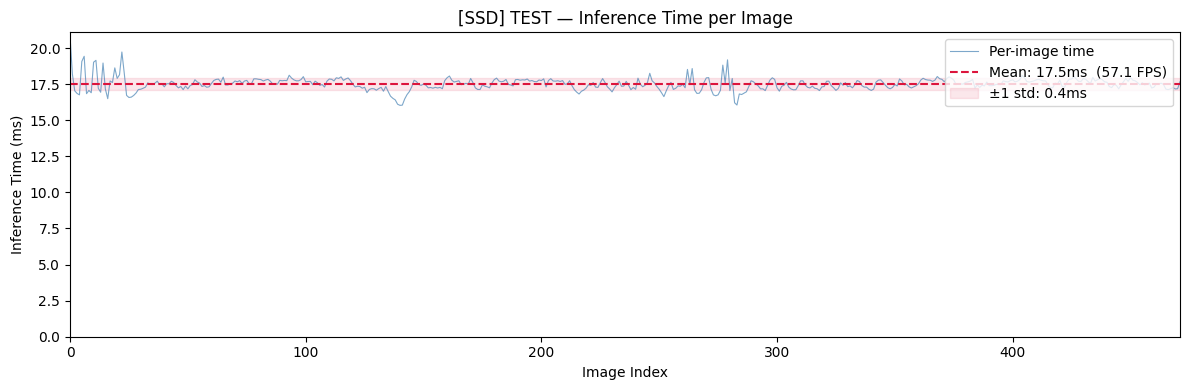

In [23]:
results = evaluate_split(ssd_model, split='test', mod_type='ssd')
print_summary(results)
plot_timing(results)


────────────────────────────────────────
  [RCNN] TEST RESULTS  (472 images)
────────────────────────────────────────
  Overall IoU    : 0.6019
  Overall score  : 0.9008
  Mean IoU       : 0.8498
  Precision      : 0.8635
  Recall         : 0.7975
  F1 score       : 0.8292
────────────────────────────────────────
  TP: 386  FP: 61  FN: 98
────────────────────────────────────────
  Total time     : 39.958s
  Avg time/image : 81.286ms
  FPS            : 12.30
────────────────────────────────────────



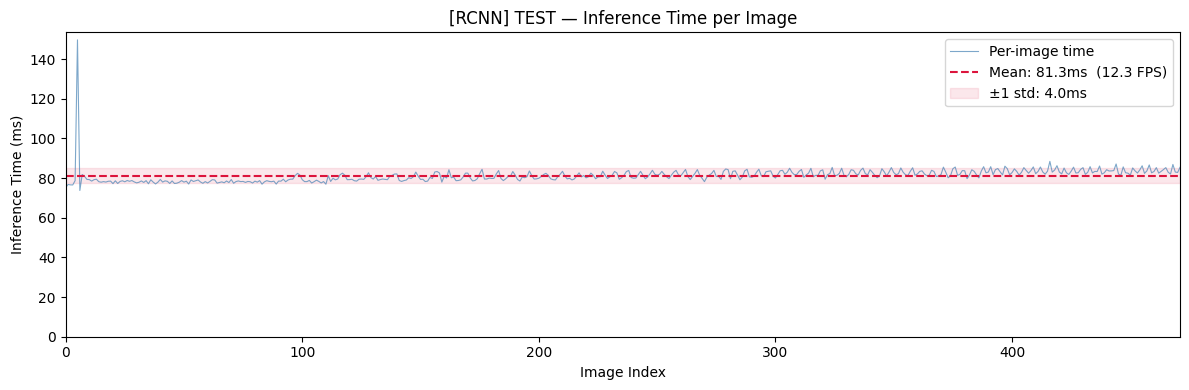

In [24]:
results = evaluate_split(rcnn_model, split='test', mod_type='rcnn')
print_summary(results)
plot_timing(results)


────────────────────────────────────────
  [YOLO] TEST RESULTS  (472 images)
────────────────────────────────────────
  Overall IoU    : 0.4503
  Overall score  : 0.7527
  Mean IoU       : 0.8681
  Precision      : 0.7908
  Recall         : 0.6012
  F1 score       : 0.6831
────────────────────────────────────────
  TP: 291  FP: 77  FN: 193
────────────────────────────────────────
  Total time     : 9.863s
  Avg time/image : 15.979ms
  FPS            : 62.58
────────────────────────────────────────



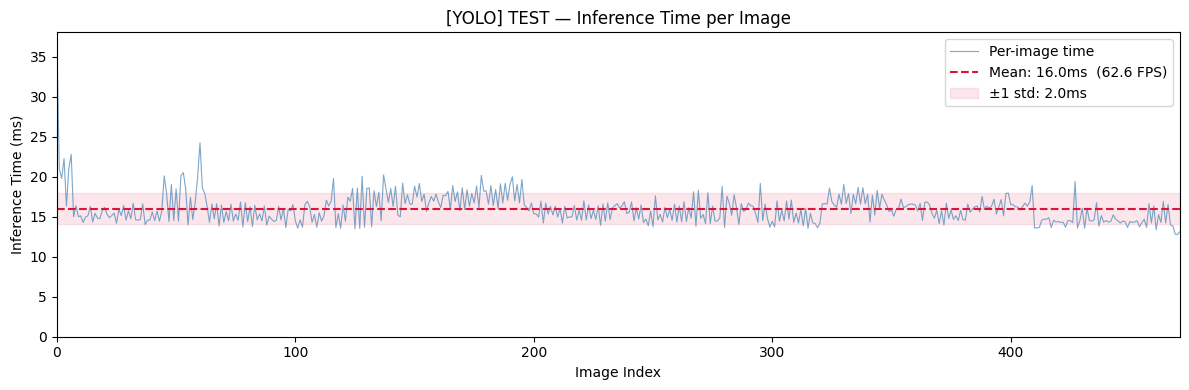

In [32]:
# results = evaluate_split(yolo_model, split='test', mod_type='yolo')
# print_summary(results)
# plot_timing(results)

In [49]:
def evaluate_model(model_path, yaml_path, class_idx=0):
    model = YOLO(model_path)
    metrics = model.val(
        data=yaml_path,
        split="test",
        conf=0.3,
        iou=0.5,
        classes=[class_idx]
    )

    precision  = metrics.box.mp
    recall     = metrics.box.mr
    map50      = metrics.box.map50
    map5095    = metrics.box.map
    f1         = 2 * (precision * recall) / (precision + recall + 1e-16)

    # TP / FP / FN from confusion matrix
    cm = metrics.confusion_matrix.matrix
    TP = int(cm[0, 0])
    FP = int(cm[0, -1])
    FN = int(cm[-1, 0])

    # Timing
    speed          = metrics.speed
    preprocess_ms  = speed.get("preprocess",  0)
    inference_ms   = speed.get("inference",   0)
    postprocess_ms = speed.get("postprocess", 0)
    avg_ms         = preprocess_ms + inference_ms + postprocess_ms
    fps            = 1000.0 / avg_ms if avg_ms > 0 else 0.0

    print(f"\n{'─'*40}")
    print(f"  [YOLO] TEST RESULTS)")
    print(f"{'─'*40}")
    print(f"  Precision      : {precision:.4f}")
    print(f"  Recall         : {recall:.4f}")
    print(f"  F1 score       : {f1:.4f}")
    print(f"  mAP@0.5        : {map50:.4f}")
    print(f"  mAP@0.5:0.95   : {map5095:.4f}")
    print(f"{'─'*40}")
    print(f"  TP: {TP}  FP: {FP}  FN: {FN}")
    print(f"{'─'*40}")
    print(f"  Preprocess     : {preprocess_ms:.2f} ms/img")
    print(f"  Inference      : {inference_ms:.2f} ms/img")
    print(f"  Postprocess    : {postprocess_ms:.2f} ms/img")
    print(f"  Avg time/image : {avg_ms:.2f} ms")
    print(f"  FPS            : {fps:.1f}")
    print(f"{'─'*40}")

    return {
        "Precision":        precision,
        "Recall":           recall,
        "F1":               f1,
        "mAP@0.5":          map50,
        "mAP@0.5:0.95":     map5095,
        "TP":               TP,
        "FP":               FP,
        "FN":               FN,
        "avg_ms_per_image": round(avg_ms, 3),
        "fps":              round(fps, 2),
    }

evaluate_model(
    YOLO_PATH, 
    "/kaggle/working/Basketball-1-yolo/data.yaml", 
    class_idx=0
)


Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1016.7±248.7 MB/s, size: 28.8 KB)
val: Scanning /kaggle/working/Basketball-1-yolo/test/labels.cache... 472 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 472/472 165.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 6.6it/s 4.6s0.1s
                   all        472        484      0.972      0.917      0.921      0.689
            basketball        463        484      0.972      0.917      0.921      0.689
Speed: 1.3ms preprocess, 3.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /kaggle/working/runs/detect/val10

────────────────────────────────────────
  [YOLO] TEST RESULTS)
────────────────────────────────────────
  Precision      : 0.9715
  Recall         : 0.9167
  F1

{'Precision': np.float64(0.9715345549156589),
 'Recall': np.float64(0.9167242479313412),
 'F1': np.float64(0.9433339146641677),
 'mAP@0.5': np.float64(0.9208054322511815),
 'mAP@0.5:0.95': np.float64(0.6888783611160608),
 'TP': 449,
 'FP': 16,
 'FN': 32,
 'avg_ms_per_image': 6.702,
 'fps': 149.21}

In [39]:
!pip install ensemble-boxes

In [50]:
import torch
import numpy as np
from ultralytics import YOLO
import torchvision
from ensemble_boxes import weighted_boxes_fusion

def get_yolo_predictions(model, image_path, conf_thresh=0.3):
    """Returns normalized [x1,y1,x2,y2], scores, labels"""
    results = model(image_path, conf=conf_thresh, verbose=False)[0]
    boxes  = results.boxes.xyxyn.cpu().numpy()   # already normalized
    scores = results.boxes.conf.cpu().numpy()
    labels = results.boxes.cls.cpu().numpy().astype(int)
    return boxes, scores, labels


def get_ssd_predictions(model, transform, image_path, device, conf_thresh=0.3):
    """Returns normalized [x1,y1,x2,y2], scores, labels"""
    from PIL import Image
    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    input_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        predictions = model(input_tensor)

    pred   = predictions[0]
    boxes  = pred["boxes"].cpu().numpy()
    scores = pred["scores"].cpu().numpy()
    labels = pred["labels"].cpu().numpy().astype(int)

    # Filter by confidence
    mask   = scores >= conf_thresh
    boxes, scores, labels = boxes[mask], scores[mask], labels[mask]

    # Normalize to [0, 1]
    boxes[:, [0, 2]] /= w
    boxes[:, [1, 3]] /= h
    boxes = np.clip(boxes, 0, 1)

    return boxes, scores, labels

In [51]:
def ensemble_predict(yolo_model, ssd_model, ssd_transform, image_path,
                     device, conf_thresh=0.3, iou_thresh=0.5,
                     yolo_weight=1.5, ssd_weight=1.0):
    """
    Run both models and fuse with WBF.
    yolo_weight > ssd_weight reflects YOLO's higher precision.
    """
    yolo_boxes, yolo_scores, yolo_labels = get_yolo_predictions(
        yolo_model, image_path, conf_thresh)
    ssd_boxes, ssd_scores, ssd_labels = get_ssd_predictions(
        ssd_model, ssd_transform, image_path, device, conf_thresh)

    # WBF expects a list of predictions per model
    boxes_list  = [yolo_boxes.tolist(),  ssd_boxes.tolist()]
    scores_list = [yolo_scores.tolist(), ssd_scores.tolist()]
    labels_list = [yolo_labels.tolist(), ssd_labels.tolist()]
    weights     = [yolo_weight, ssd_weight]

    fused_boxes, fused_scores, fused_labels = weighted_boxes_fusion(
        boxes_list,
        scores_list,
        labels_list,
        weights=weights,
        iou_thr=iou_thresh,
        skip_box_thr=conf_thresh       # discard boxes below this after fusion
    )

    return fused_boxes, fused_scores, fused_labels.astype(int)

In [58]:
from pathlib import Path
import cv2

def evaluate_ensemble(yolo_model, ssd_model, ssd_transform,
                      test_dir, label_dir, device,
                      conf_thresh=0.3, iou_thresh=0.5):
    tp, fp, fn = 0, 0, 0
    iou_scores = []  # collect per-match IoU

    image_paths = list(Path(test_dir).glob("*.jpg")) + \
                  list(Path(test_dir).glob("*.png"))

    for img_path in image_paths:
        label_path = Path(label_dir) / (img_path.stem + ".txt")
        gt_boxes   = load_gt_boxes(label_path)

        pred_boxes, pred_scores, pred_labels = ensemble_predict(
            yolo_model, ssd_model, ssd_transform,
            str(img_path), device, conf_thresh, iou_thresh,
        )

        mask       = pred_labels == 0
        pred_boxes = pred_boxes[mask]

        t, f_pos, f_neg, match_ious = compute_tp_fp_fn(gt_boxes, pred_boxes, iou_thresh)
        tp += t; fp += f_pos; fn += f_neg
        iou_scores.extend(match_ious)  # accumulate matched IoUs

    precision = tp / (tp + fp + 1e-16)
    recall    = tp / (tp + fn + 1e-16)
    f1        = 2 * precision * recall / (precision + recall + 1e-16)
    mean_iou  = float(np.mean(iou_scores)) if iou_scores else 0.0

    print(f"{'─'*40}")
    print(f"  TP: {tp}  FP: {fp}  FN: {fn}")
    print(f"{'─'*40}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1        : {f1:.4f}")
    print(f"  Mean IoU  : {mean_iou:.4f}")
    print(f"{'─'*40}")

    return {"precision": precision, "recall": recall,
            "f1": f1, "mean_iou": mean_iou,
            "TP": tp, "FP": fp, "FN": fn}


def load_gt_boxes(label_path):
    """Load YOLO-format labels → normalized [x1,y1,x2,y2]"""
    boxes = []
    if not label_path.exists():
        return np.array([])
    with open(label_path) as f:
        for line in f:
            _, cx, cy, w, h = map(float, line.strip().split())
            x1, y1 = cx - w/2, cy - h/2
            x2, y2 = cx + w/2, cy + h/2
            boxes.append([x1, y1, x2, y2])
    return np.array(boxes)


def compute_tp_fp_fn(gt_boxes, pred_boxes, iou_thresh=0.5):
    """Greedy IoU matching. Now also returns list of matched IoU values."""
    if len(gt_boxes) == 0:
        return 0, len(pred_boxes), 0, []
    if len(pred_boxes) == 0:
        return 0, 0, len(gt_boxes), []

    matched_gt  = set()
    tp          = 0
    match_ious  = []  # IoU for each TP match

    for pb in pred_boxes:
        ious = compute_iou_batch(pb, gt_boxes)
        best = np.argmax(ious)
        if ious[best] >= iou_thresh and best not in matched_gt:
            tp += 1
            matched_gt.add(best)
            match_ious.append(float(ious[best]))  # only TPs contribute

    fp = len(pred_boxes) - tp
    fn = len(gt_boxes)   - tp
    return tp, fp, fn, match_ious


def compute_iou_batch(box, gt_boxes):
    """IoU between one pred box and all GT boxes."""
    x1 = np.maximum(box[0], gt_boxes[:, 0])
    y1 = np.maximum(box[1], gt_boxes[:, 1])
    x2 = np.minimum(box[2], gt_boxes[:, 2])
    y2 = np.minimum(box[3], gt_boxes[:, 3])
    inter = np.maximum(0, x2-x1) * np.maximum(0, y2-y1)
    area_pred = (box[2]-box[0]) * (box[3]-box[1])
    area_gt   = (gt_boxes[:,2]-gt_boxes[:,0]) * (gt_boxes[:,3]-gt_boxes[:,1])
    return inter / (area_pred + area_gt - inter + 1e-16)

In [59]:
# # Load models
# yolo_model = YOLO("best.pt")

# ssd_model = torch.load("ssd_model.pth", map_location=device)
# ssd_model.eval()

ssd_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((300, 300)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
])

# Evaluate
evaluate_ensemble(
    yolo_model, ssd_model, ssd_transform,
    test_dir   = "/kaggle/working/Basketball-1-yolo/test/images",
    label_dir  = "/kaggle/working/Basketball-1-yolo/test/labels",
    device     = DEVICE,
)

────────────────────────────────────────
  TP: 449  FP: 25  FN: 85
────────────────────────────────────────
  Precision : 0.9473
  Recall    : 0.8408
  F1        : 0.8909
  Mean IoU  : 0.8654
────────────────────────────────────────


{'precision': 0.9472573839662447,
 'recall': 0.8408239700374532,
 'f1': 0.8908730158730159,
 'mean_iou': 0.8653633920654065,
 'TP': 449,
 'FP': 25,
 'FN': 85}